In [2]:
!pip install -U transformers datasets accelerate bitsandbytes scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pand

In [1]:
import os, re, json, random, inspect
import numpy as np
import pandas as pd
import torch
import bitsandbytes as bnb
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    AutoModelForSequenceClassification, DataCollatorWithPadding,
    Trainer, TrainingArguments, set_seed
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
LABELS = [
    "transfer_status", "transfer_cancel", "transfer_wrong_recipient",
    "card_payment_declined", "card_payment_pending", "cash_withdrawal_issue",
    "card_blocked", "card_expired", "card_delivery",
    "credit_application_status", "credit_payment", "credit_early_repayment",
    "credit_rate_terms", "account_statement", "cash_deposit"
]

LABEL_INFO = {
    "transfer_status": ("статус денежного перевода", "где перевод, почему не дошёл, сколько ждать"),
    "transfer_cancel": ("отмена перевода", "можно ли отменить уже отправленный перевод"),
    "transfer_wrong_recipient": ("ошибка в реквизитах/получателе", "перевод отправлен не тому получателю или с неверными реквизитами"),
    "card_payment_declined": ("отклонённая покупка по карте", "почему не проходит оплата покупки картой"),
    "card_payment_pending": ("платёж картой в обработке", "покупка зависла, деньги зарезервированы, операция не завершена"),
    "cash_withdrawal_issue": ("проблема со снятием наличных", "не удалось снять наличные или операция банкомата отобразилась некорректно"),
    "card_blocked": ("заблокированная карта", "карта заблокирована, захвачена банкоматом или не работает"),
    "card_expired": ("срок действия карты", "что делать из-за окончания срока действия"),
    "card_delivery": ("доставка карты", "когда доставят карту, где она и как отследить"),
    "credit_application_status": ("статус заявки на кредит", "что с заявкой и когда будет решение"),
    "credit_payment": ("платёж по кредиту", "как внести ближайший платёж и где реквизиты"),
    "credit_early_repayment": ("досрочное погашение кредита", "как частично или полностью погасить раньше срока"),
    "credit_rate_terms": ("ставка и условия кредита", "ставка, срок, переплата, требования"),
    "account_statement": ("выписка по счёту", "получение выписки и истории операций"),
    "cash_deposit": ("пополнение счёта/карты", "как внести деньги и какие ограничения"),
}

READY_RESPONSES = {
    "transfer_status": "Проверим статус перевода и сроки его зачисления.",
    "transfer_cancel": "Проверим, доступна ли отмена перевода на текущем этапе.",
    "transfer_wrong_recipient": "Проверим перевод и доступные действия при ошибке в реквизитах или получателе.",
    "card_payment_declined": "Проверим причину отклонения операции и состояние карты.",
    "card_payment_pending": "Проверим операцию в обработке и статус зарезервированных средств.",
    "cash_withdrawal_issue": "Проверим операцию снятия наличных и её текущий статус.",
    "card_blocked": "Проверим статус карты и варианты разблокировки или перевыпуска.",
    "card_expired": "Проверим срок действия и порядок перевыпуска карты.",
    "card_delivery": "Проверим статус доставки карты и доступный трекинг.",
    "credit_application_status": "Проверим статус заявки и этап рассмотрения.",
    "credit_payment": "Подскажем способ и реквизиты для ближайшего платежа.",
    "credit_early_repayment": "Подскажем порядок полного или частичного досрочного погашения.",
    "credit_rate_terms": "Подскажем актуальные ставку, срок и основные требования.",
    "account_statement": "Подскажем, как получить выписку или историю операций.",
    "cash_deposit": "Подскажем доступные способы пополнения и ограничения."
}


In [17]:
GEN_PER_CLASS = 30

In [18]:
GENERATOR_MODEL = "Qwen/Qwen2.5-7B-Instruct"


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

gen_tokenizer = AutoTokenizer.from_pretrained(GENERATOR_MODEL)
gen_model = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype="auto",
)
if gen_tokenizer.pad_token is None:
    gen_tokenizer.pad_token = gen_tokenizer.eos_token

print("Loaded:", GENERATOR_MODEL)


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-7B-Instruct


In [21]:
def extract_json_array(text):

  text = text.strip()
  text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
  text = re.sub(r"^```\s*", "", text)
  text = re.sub(r"\s*```$", "", text)

  start = text.find("[")
  end = text.rfind("]")

  if start == -1 or end == -1 or end <= start:
      raise ValueError(
          "JSON array not found.\n\n"
          "Ответ модели:\n" + text[:3000]
      )

  candidate = text[start:end + 1]
  try:
      return json.loads(candidate)
  except json.JSONDecodeError as e:
      raise ValueError(
          f"JSON найден, но он некорректный: {e}\n\n"
          f"Ответ модели:\n{candidate[:3000]}"
      )


def generate_one_dialog(label):
    prompt = f"""
Ты — специалист по созданию высококачественных датасетов для обучения моделей классификации клиентских обращений в банковской поддержке.
Твоя задача — создать диалог клиента с банковской поддержкой.
Сгенерируй ОДИН короткий банковский диалог на РУССКОМ языке на тему: {label}
Последняя реплика ОБЯЗАТЕЛЬНО должна соответствовать классу "{label}" и быть от user. При этом название самой метки НЕ УКАЗЫВАТЬ.
Описание темы:
{LABEL_INFO[label]}

Диалог должен содержать:
- user
- assistant

Верни только этот JSON-объект:

{{
  "label": "{label}",
  "dialog": "user: ...\\nassistant: ...\\nuser: ..."
}}

Не добавляй никаких пояснений.
Не используй markdown.
"""

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = gen_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = gen_tokenizer(
        text,
        return_tensors="pt"
    ).to(gen_model.device)

    output_ids = gen_model.generate(
        **inputs,
        max_new_tokens=500,
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )

    generated_text = gen_tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    print(generated_text)

    start = generated_text.find("{")
    end = generated_text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("JSON object not found")
    if "label" not in generated_text:
        raise ValueError
    candidate = generated_text[start:end + 1]
    return json.loads(candidate)

In [ ]:
all_rows = []

for i, label in enumerate(LABELS[5], 1):
    rows = []
    while len(rows) < GEN_PER_CLASS:
        try:
            row = generate_one_dialog(label)
            rows.append(row)
            print(
                f"{label}: "
                f"{len(rows)}/{GEN_PER_CLASS}"
            )

        except Exception as e:
            print("Ошибка генерации:", e)
            print("Повторяем запрос...")
    all_rows.extend(rows)
    print(
        f"{i}/{len(LABELS)} "
        f"{label} -> {len(rows)}"
    )

df = pd.DataFrame(all_rows)
print("\nВсего:", len(df))

display(df.head())
display(df["label"].value_counts())


{
  "label": "credit_application_status",
  "dialog": "user: Здравствуйте, подскажите пожалуйста статус моей заявки на кредит?\nassistant: Добрый день! Ваша заявка на кредит уже рассмотрена. В данный момент она находится в ожидании окончательного решения.\nuser: Когда можно будет узнать результат?"
}
credit_application_status: 1/30
{
  "label": "credit_application_status",
  "dialog": "user: Добрый день, я подавал заявку на кредит еще неделю назад, хотел бы узнать статус моего запроса.\nassistant: Добрый день! Спасибо за обращение. Ваша заявка на рассмотрении уже более недели. В ближайшее время мы свяжемся с вами для уведомления о решении.\nuser: credit_application_status: Я понимаю, когда вы предполагаете дать ответ?"
}
credit_application_status: 2/30
{
  "label": "credit_application_status",
  "dialog": "user: Здравствуйте, я подавал заявку на кредит неделю назад, можно узнать статус моего дела?\nassistant: Добрый день, ваша заявка на рассмотрении. В ближайшее время вы получите инфор

,label,dialog
0,credit_application_status,"user: Здравствуйте, подскажите пожалуйста стат..."
1,credit_application_status,"user: Добрый день, я подавал заявку на кредит ..."
2,credit_application_status,"user: Здравствуйте, я подавал заявку на кредит..."
3,credit_application_status,"user: Здравствуйте, я подавал заявку на кредит..."
4,credit_application_status,user: Могу ли я узнать статус моей заявки на к...


label
credit_application_status    30
credit_payment               30
credit_early_repayment       30
credit_rate_terms            30
account_statement            30
cash_deposit                 30
Name: count, dtype: int64

Использовал данный код в связи с ограниченными ресурсами Google Colab

In [52]:
# from google.colab import files
# files.upload()
# import pickle
# with open("my_list.pkl", "rb") as f:
#   all_rows = pickle.load(f)
# print(len(all_rows))


In [53]:
# a = []
# with open("my_list1.pkl", "rb") as f:
#   a = pickle.load(f)
# all_rows.extend(a)
# print(len(all_rows))


In [38]:
df = pd.DataFrame(all_rows)
print("\nВсего:", len(df))

display(df.head())
display(df["label"].value_counts())


Всего: 450


,label,dialog
0,transfer_status,"user: Здравствуйте, пожалуйста, проверьте стат..."
1,transfer_status,"user: Здравствуйте, можно узнать статус моего ..."
2,transfer_status,"user: Здравствуйте, можно узнать статус моего ..."
3,transfer_status,"user: Здравствуйте, пожалуйста, проверьте стат..."
4,transfer_status,"user: Здравствуйте, пожалуйста, помогите мне у..."


label
transfer_status              30
transfer_cancel              30
transfer_wrong_recipient     30
card_payment_declined        30
card_payment_pending         30
card_blocked                 30
card_expired                 30
card_delivery                30
credit_application_status    30
credit_payment               30
credit_early_repayment       30
credit_rate_terms            30
account_statement            30
cash_deposit                 30
cash_withdrawal_issue        30
Name: count, dtype: int64

In [39]:
df.to_csv("dataset2.csv", index=False, encoding="utf-8-sig")
from google.colab import files
files.download("dataset2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
for label in LABELS:
    row = df[df["label"] == label].iloc[0]
    print("=" * 90)
    print(label)
    print(row["dialog"])


transfer_status
user: Здравствуйте, пожалуйста, проверьте статус моего перевода, я его отправил вчера.
assistant: Добрый день! Спасибо за обращение. Проверю информацию о вашем переводе.
user: Да, пожалуйста, ускорите процесс, если возможно.
transfer_cancel
user: Можно ли отменить уже отправленный перевод?
assistant: Да, вы можете отменить перевод в течение первых 24 часов после его отправки.
user: Как это сделать?

transfer_wrong_recipient
user: Я заметил, что перевод был отправлен не тому получателю. Правильно указан номер счета?
assistant: Да, проверим это для вас. Пожалуйста, подождите, я сделаю запрос.
user: ...
card_payment_declined
user: Почему мою карту отклонили при попытке оплатить товар?
assistant: Добрый день! Извините за доставшуюся неудобство. Возможно, произошло несколько ситуаций, почему платеж был отклонен. Например, недостаточно средств на счете или проблема с картой.
user: У меня достаточно средств на счете, что еще может быть?
card_payment_pending
user: Здравствуйте,

In [41]:
train_parts, test_parts = [], []

for label in LABELS:
    part = df[df["label"] == label].sample(frac=1, random_state=SEED).reset_index(drop=True)
    train_parts.append(part.iloc[:20])
    test_parts.append(part.iloc[20:30])
train_df = pd.concat(train_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

train_df["labels"] = train_df["label"].map(label2id)
test_df["labels"] = test_df["label"].map(label2id)

display(pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index()
}))


,train,test
label,,
account_statement,20,10
card_blocked,20,10
card_delivery,20,10
card_expired,20,10
card_payment_declined,20,10
card_payment_pending,20,10
cash_deposit,20,10
cash_withdrawal_issue,20,10
credit_application_status,20,10


In [42]:
CLASSIFIER_MODEL = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(
    CLASSIFIER_MODEL,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)

def tokenize_batch(batch):
    return tokenizer(batch["dialog"], truncation=True, max_length=384)

train_ds = Dataset.from_pandas(train_df[["dialog", "labels"]], preserve_index=False).map(tokenize_batch, batched=True)
test_ds = Dataset.from_pandas(test_df[["dialog", "labels"]], preserve_index=False).map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro"),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
    }


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [43]:
params = inspect.signature(TrainingArguments.__init__).parameters
kwargs = dict(
    output_dir="./bank_intent_classifier",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)
kwargs["eval_strategy" if "eval_strategy" in params else "evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.713904,2.685768,0.200000,0.129733,0.194028,0.200000
2,2.685034,2.658086,0.366667,0.315499,0.415250,0.366667
3,2.648694,2.627083,0.553333,0.489357,0.468199,0.553333
4,2.621960,2.601354,0.600000,0.536042,0.541900,0.600000
5,2.592383,2.590677,0.626667,0.558967,0.538521,0.626667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=95, training_loss=2.648461482399388, metrics={'train_runtime': 29.9103, 'train_samples_per_second': 50.15, 'train_steps_per_second': 3.176, 'total_flos': 2009126580120.0, 'train_loss': 2.648461482399388, 'epoch': 5.0})

In [44]:
metrics = trainer.evaluate()
print(json.dumps(metrics, indent=2, ensure_ascii=False))


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
2.592383,2.590677,5,0.626667,0.558967,0.538521,0.626667


{
  "eval_loss": 2.590676784515381,
  "eval_accuracy": 0.6266666666666667,
  "eval_f1": 0.5589671976768751,
  "eval_precision": 0.5385209235209235,
  "eval_recall": 0.6266666666666667
}


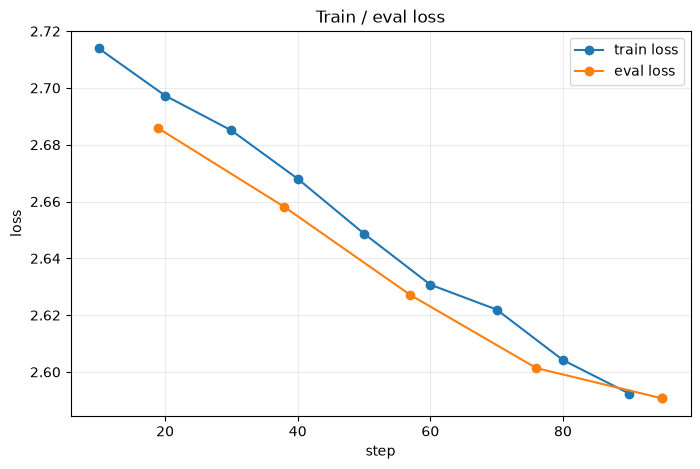

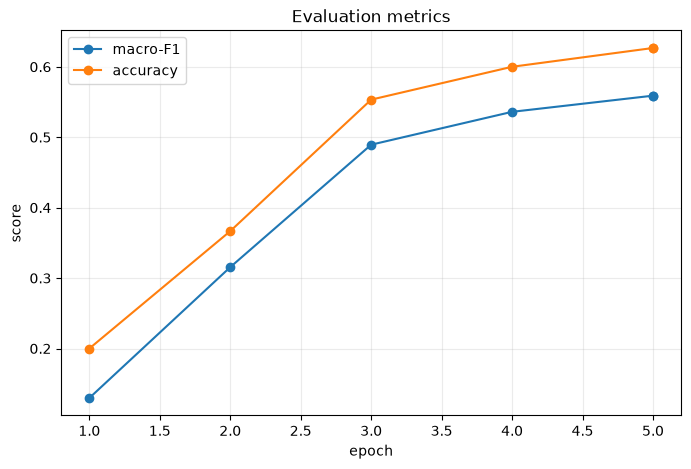

In [45]:
history = pd.DataFrame(trainer.state.log_history)

plt.figure(figsize=(8, 5))
if "loss" in history:
    h = history[history["loss"].notna()]
    plt.plot(h["step"], h["loss"], marker="o", label="train loss")
if "eval_loss" in history:
    h = history[history["eval_loss"].notna()]
    plt.plot(h["step"], h["eval_loss"], marker="o", label="eval loss")
plt.title("Train / eval loss")
plt.xlabel("step"); plt.ylabel("loss")
plt.legend(); plt.grid(alpha=.25); plt.show()

plt.figure(figsize=(8, 5))
h = history[history["eval_f1"].notna()] if "eval_f1" in history else pd.DataFrame()
if not h.empty:
    plt.plot(h["epoch"], h["eval_f1"], marker="o", label="macro-F1")
if "eval_accuracy" in history and not h.empty:
    plt.plot(h["epoch"], h["eval_accuracy"], marker="o", label="accuracy")
plt.title("Evaluation metrics")
plt.xlabel("epoch"); plt.ylabel("score")
plt.legend(); plt.grid(alpha=.25); plt.show()


In [46]:
pred = trainer.predict(test_ds)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=-1)

report = classification_report(
    y_true, y_pred,
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    output_dict=True,
    zero_division=0
)
display(pd.DataFrame(report).T.round(3))


,precision,recall,f1-score,support
transfer_status,0.455,0.500,0.476,10.000
transfer_cancel,0.833,1.000,0.909,10.000
transfer_wrong_recipient,0.727,0.800,0.762,10.000
card_payment_declined,0.400,0.400,0.400,10.000
card_payment_pending,0.000,0.000,0.000,10.000
cash_withdrawal_issue,0.750,0.900,0.818,10.000
card_blocked,0.500,0.600,0.545,10.000
card_expired,0.450,0.900,0.600,10.000
card_delivery,0.000,0.000,0.000,10.000
credit_application_status,1.000,0.400,0.571,10.000


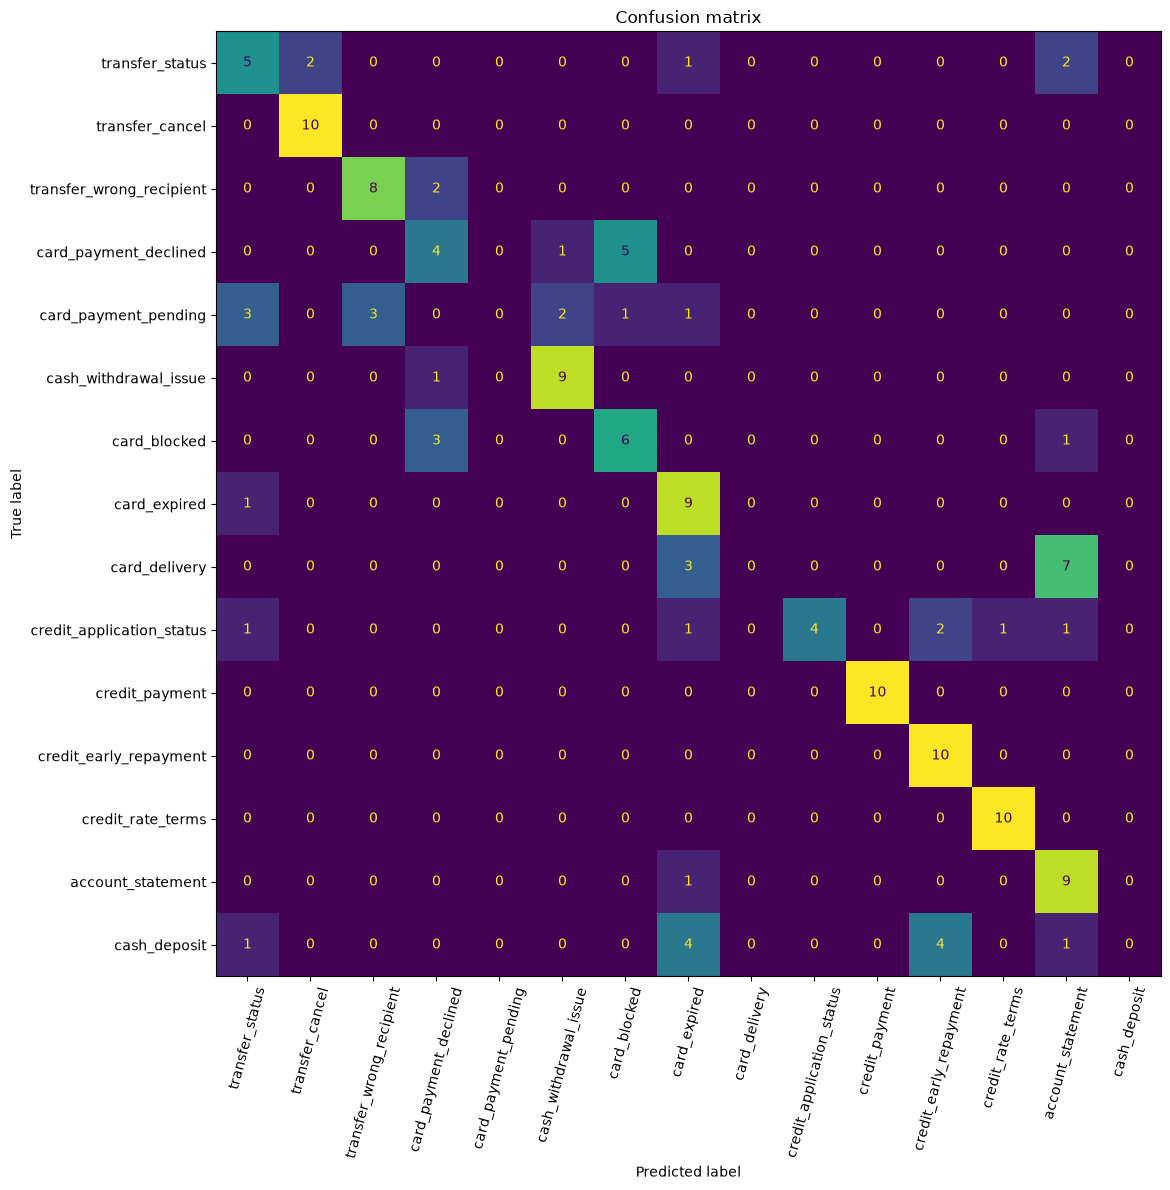

In [47]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, xticks_rotation=75, colorbar=False)
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()


In [48]:
def predict_dialog(dialog):
    model.eval()
    inputs = tokenizer(dialog, return_tensors="pt", truncation=True, max_length=384)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1)[0]
    p, idx = torch.topk(probs, 3)
    return [(id2label[int(i)], float(v), READY_RESPONSES[id2label[int(i)]]) for v, i in zip(p.cpu(), idx.cpu())]

demo = []
for label in LABELS:
    row = test_df[test_df["label"] == label].iloc[0]
    top1 = predict_dialog(row["dialog"])[0]
    demo.append((label, top1[0], round(top1[1], 3)))

display(pd.DataFrame(demo, columns=["true_label", "pred_label", "confidence"]))

for label in LABELS:
    dialog = test_df[test_df["label"] == label].iloc[0]["dialog"]
    top3 = predict_dialog(dialog)
    print("=" * 100)
    print("TRUE:", label)
    print(dialog)
    print("TOP-3:", [(x[0], round(x[1], 3)) for x in top3])


,true_label,pred_label,confidence
0,transfer_status,transfer_status,0.073
1,transfer_cancel,transfer_cancel,0.082
2,transfer_wrong_recipient,transfer_wrong_recipient,0.075
3,card_payment_declined,card_payment_declined,0.074
4,card_payment_pending,transfer_wrong_recipient,0.070
5,cash_withdrawal_issue,cash_withdrawal_issue,0.076
6,card_blocked,card_blocked,0.073
7,card_expired,card_expired,0.078
8,card_delivery,account_statement,0.080
9,credit_application_status,credit_early_repayment,0.072


TRUE: transfer_status
user: Здравствуйте, можно узнать статус моего перевода в размере 50 000 рублей, который я сделал вчера?
assistant: Понял вас. Давайте проверим информацию о вашем платеже. Время ожидания обычно составляет около 2-3 рабочих дней.
user: transfer_status: Я пока не получил деньги на карту, когда можно будет узнать точное время прихода перевода?
TOP-3: [('transfer_status', 0.073), ('transfer_cancel', 0.072), ('account_statement', 0.07)]
TRUE: transfer_cancel
user: Могу ли я отменить уже отправленный перевод?
assistant: Да, вы можете отменить перевод, но это зависит от того, когда было сделано переведение.
user: Как это сделать?
TOP-3: [('transfer_cancel', 0.082), ('card_expired', 0.073), ('account_statement', 0.072)]
TRUE: transfer_wrong_recipient
user: Здравствуйте, произошла ошибка при переводе денег. Я перевел деньги не тому получателю.
assistant: Понял вас, это может быть связано с ошибкой в реквизитах. Можете предоставить детали вашей транзакции?
user: Да, конечно.

In [49]:
new_dialog = """user: Здравствуйте! Подскажите по моему кредиту.
assistant: Конечно. Что именно вы хотели узнать?
user: Хочу закрыть кредит раньше срока, как это сделать?"""

print(new_dialog)
for label, prob, answer in predict_dialog(new_dialog):
    print(f"{label:28s} p={prob:.4f} | {answer}")


user: Здравствуйте! Подскажите по моему кредиту.
assistant: Конечно. Что именно вы хотели узнать?
user: Хочу закрыть кредит раньше срока, как это сделать?
credit_early_repayment       p=0.0724 | Подскажем порядок полного или частичного досрочного погашения.
credit_payment               p=0.0719 | Подскажем способ и реквизиты для ближайшего платежа.
card_expired                 p=0.0704 | Проверим срок действия и порядок перевыпуска карты.


In [51]:
df.to_json("bank_support_synthetic.jsonl", orient="records", lines=True, force_ascii=False)
train_df.to_json("bank_support_train.jsonl", orient="records", lines=True, force_ascii=False)
test_df.to_json("bank_support_test.jsonl", orient="records", lines=True, force_ascii=False)

trainer.save_model("./bank_intent_classifier")
tokenizer.save_pretrained("./bank_intent_classifier")

with open("label_map.json", "w", encoding="utf-8") as f:
    json.dump(
        {"label2id": label2id, "id2label": id2label, "ready_responses": READY_RESPONSES},
        f, ensure_ascii=False, indent=2
    )



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]